# Squad 2 - Real Time for Business

## Análise Exploratória - ecommerce_pedidos

**Dupla 3**

Integrantes:
- Eduardo Geraldo de Souza
- Aliedson Soares Silva


## Objetivo

Este notebook apresenta a análise exploratória da tabela `ecommerce_pedidos`.

Serão analisados:

- estrutura dos dados;
- qualidade das informações;
- comportamento dos pedidos;
- indicadores comerciais;
- métricas relevantes para análise de negócio.

Tabela responsável:

`squad2.ecommerce_pedidos`

In [5]:
# --------------------------------------------------
# IMPORTAÇÃO DAS BIBLIOTECAS
# --------------------------------------------------

# Biblioteca principal para análise de dados
import pandas as pd


# Biblioteca para cálculos numéricos
import numpy as np


# Biblioteca para gráficos
import matplotlib.pyplot as plt


# Biblioteca para acessar variáveis do sistema
import os


# Biblioteca para carregar o arquivo .env
from dotenv import load_dotenv


# Biblioteca de autenticação Azure
from azure.identity import ClientSecretCredential


# Biblioteca para acessar Azure Data Lake Gen2
from azure.storage.filedatalake import DataLakeServiceClient


# Biblioteca para ler arquivos em memória
from io import StringIO


print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [6]:
# Verificar qual Python o notebook está usando

import sys

sys.executable

'c:\\Users\\eduar\\Downloads\\RealTimeBusiness_Squad2_Dupla3\\.venv\\Scripts\\python.exe'

In [7]:
# --------------------------------------------------
# CONEXÃO COM AZURE DATA LAKE
# --------------------------------------------------

# Carrega as variáveis do arquivo .env
load_dotenv()


# Recupera as credenciais do Azure
client_id = os.getenv(
    "ADLS_CLIENT_ID"
)

tenant_id = os.getenv(
    "ADLS_TENANT_ID"
)

client_secret = os.getenv(
    "ADLS_CLIENT_SECRET"
)


# Nome da conta de armazenamento
storage_account = os.getenv(
    "STORAGE_ACCOUNT"
)



# --------------------------------------------------
# AUTENTICAÇÃO AZURE
# --------------------------------------------------

# Cria a credencial usando:
# - tenant_id
# - client_id
# - client_secret

credential = ClientSecretCredential(
    tenant_id,
    client_id,
    client_secret
)



# --------------------------------------------------
# CRIAR CLIENTE DO DATA LAKE
# --------------------------------------------------

# Endereço da conta Azure

account_url = (
    f"https://{storage_account}.dfs.core.windows.net"
)


# Cliente principal do Data Lake

service_client = DataLakeServiceClient(
    account_url=account_url,
    credential=credential
)



# Acessa o container raw

file_system_client = service_client.get_file_system_client(
    file_system="raw"
)


print(
    "Conexão com Data Lake realizada com sucesso!"
)

Conexão com Data Lake realizada com sucesso!


# 1. Conexão com Azure Data Lake Storage Gen2

Nesta etapa é realizada a conexão com o Azure Data Lake Storage Gen2, ambiente onde estão armazenados os dados brutos utilizados pela Squad 2.

## Fonte dos dados

- Serviço: Azure Data Lake Storage Gen2
- Container: `raw`
- Tabela analisada:


A autenticação foi realizada utilizando as credenciais fornecidas para o ambiente do estágio.

As credenciais são armazenadas no arquivo `.env`, que não é versionado por conter informações sensíveis.

In [8]:
# --------------------------------------------------
# 1. CONEXÃO COM AZURE DATA LAKE STORAGE GEN2
# --------------------------------------------------

# Biblioteca para variáveis de ambiente
import os


# Carregar arquivo .env
from dotenv import load_dotenv


# Autenticação Azure
from azure.identity import ClientSecretCredential


# Cliente ADLS Gen2
from azure.storage.filedatalake import DataLakeServiceClient



# --------------------------------------------------
# CARREGAR VARIÁVEIS DO .ENV
# --------------------------------------------------

load_dotenv()



# Credenciais Azure

client_id = os.getenv(
    "ADLS_CLIENT_ID"
)

tenant_id = os.getenv(
    "ADLS_TENANT_ID"
)

client_secret = os.getenv(
    "ADLS_CLIENT_SECRET"
)



# Configurações do Data Lake

storage_account = os.getenv(
    "STORAGE_ACCOUNT_NAME"
)

container_name = os.getenv(
    "CONTAINER_NAME"
)



# Validação das variáveis

if not all(
    [
        client_id,
        tenant_id,
        client_secret,
        storage_account,
        container_name
    ]
):
    raise Exception(
        "Erro: Variáveis do .env não foram carregadas corretamente."
    )



print("Configurações carregadas!")
print(
    "Storage:",
    storage_account
)

print(
    "Container:",
    container_name
)



# --------------------------------------------------
# AUTENTICAÇÃO AZURE
# --------------------------------------------------

credential = ClientSecretCredential(
    tenant_id=tenant_id,
    client_id=client_id,
    client_secret=client_secret
)



print(
    "Autenticação Azure criada!"
)



# --------------------------------------------------
# CONEXÃO COM DATA LAKE
# --------------------------------------------------

account_url = (
    f"https://{storage_account}.dfs.core.windows.net"
)



service_client = DataLakeServiceClient(
    account_url=account_url,
    credential=credential
)



file_system_client = (
    service_client
    .get_file_system_client(
        file_system=container_name
    )
)



# --------------------------------------------------
# TESTE DE ACESSO
# --------------------------------------------------

teste_acesso = next(
    file_system_client.get_paths(
        path="batch-data",
        recursive=False
    ),
    None
)



print(
    "Conexão com Azure Data Lake realizada com sucesso!"
)

print(
    "Container acessado:",
    container_name
)

Configurações carregadas!
Storage: internshipdatalake
Container: raw
Autenticação Azure criada!
Conexão com Azure Data Lake realizada com sucesso!
Container acessado: raw


In [9]:
# --------------------------------------------------
# CARREGAR TABELA ECOMMERCE_CLIENTES
# --------------------------------------------------

# Caminho do arquivo dentro do Data Lake
arquivo_clientes = (
    "batch-data/ecommerce_clientes.csv"
)



# Cria o cliente para acessar o arquivo
file_client = file_system_client.get_file_client(
    arquivo_clientes
)



# Faz o download do arquivo
download = file_client.download_file()



# Converte o conteúdo para texto
conteudo = download.readall().decode(
    "utf-8"
)



# Cria o DataFrame usando pandas
df_clientes = pd.read_csv(
    StringIO(conteudo)
)



# Confirma carregamento

print(
    "Tabela ecommerce_clientes carregada!"
)


print(
    "Quantidade de registros:"
)

print(
    df_clientes.shape
)

Tabela ecommerce_clientes carregada!
Quantidade de registros:
(10000, 8)


In [10]:
# --------------------------------------------------
# VISUALIZAÇÃO INICIAL DOS DADOS
# --------------------------------------------------

# Mostra os primeiros registros
# da tabela de clientes.

df_clientes.head()

,id_cliente,uuid_cliente,nome,sobrenome,email,senha_hash,dt_cadastro,dt_ultima_atualizacao
0,1,28567b32-722c-4659-8556-2eb5dd3159ab,Bruno,da Conceição Aragão,b_aragao@gmail.com,8e36fb67dc342577d02adecffa0cec59a5a0802f24a40a...,2022-12-14 14:15:14,2023-06-24 14:15:14
1,2,1149d260-2e3f-4129-9e67-6f49e9068e3e,Elisa,Costela dos Moura,elisa.moura28@gmail.com,5197b77e5cffeb28612c17c69f2abaf0be044fd32d4b1b...,2023-08-15 06:02:12,2024-06-23 06:02:12
2,3,a360a93a-fb7e-4aa4-966b-e8e701ef34fc,Luiza,das Neves Câmara,l.camara1995@gmail.com,f0205fba2c1e0aa60ada0fdfaeabd7b04eb4470ca3fde4...,2025-06-18 11:50:32,2025-07-03 11:50:32
3,4,a0882f15-7e96-4dba-b5b7-a72569895bd8,Dom,Correia Fonseca,dom.fonseca5@hotmail.com,9a1bd4a7324cb9f593013f31fe1bb1e5dc9f42cf52a169...,2024-01-17 21:21:15,2024-07-23 21:21:15
4,5,8811cd02-b0cb-4b76-b2d6-642ec3729d43,Theo,Cardoso Cavalcante,cavalcante_theo@hotmail.com,a64edc425426b99a73a5adcce5fab268a63381b834887e...,2024-12-24 04:48:31,2025-06-07 04:48:31


In [11]:
# --------------------------------------------------
# INFORMAÇÕES DA TABELA
# --------------------------------------------------

# Mostra:
# - quantidade de registros
# - colunas
# - tipos dos dados
# - valores preenchidos

df_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id_cliente             10000 non-null  int64
 1   uuid_cliente           10000 non-null  str  
 2   nome                   10000 non-null  str  
 3   sobrenome              10000 non-null  str  
 4   email                  10000 non-null  str  
 5   senha_hash             10000 non-null  str  
 6   dt_cadastro            10000 non-null  str  
 7   dt_ultima_atualizacao  10000 non-null  str  
dtypes: int64(1), str(7)
memory usage: 625.1 KB


In [12]:
# --------------------------------------------------
# CONVERSÃO DAS DATAS
# --------------------------------------------------

# Converte a data de cadastro
# de texto para datetime.

df_clientes["dt_cadastro"] = pd.to_datetime(
    df_clientes["dt_cadastro"]
)


# Converte a data de atualização
# de texto para datetime.

df_clientes["dt_ultima_atualizacao"] = pd.to_datetime(
    df_clientes["dt_ultima_atualizacao"]
)


# Verifica novamente os tipos.

df_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_cliente             10000 non-null  int64         
 1   uuid_cliente           10000 non-null  str           
 2   nome                   10000 non-null  str           
 3   sobrenome              10000 non-null  str           
 4   email                  10000 non-null  str           
 5   senha_hash             10000 non-null  str           
 6   dt_cadastro            10000 non-null  datetime64[us]
 7   dt_ultima_atualizacao  10000 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1), str(5)
memory usage: 625.1 KB


In [13]:
# --------------------------------------------------
# CRIAR COLUNA DE MÊS DE CADASTRO
# --------------------------------------------------

# Extrai ano e mês da data de cadastro.
# Exemplo:
# 2025-06-18 11:30:00
#
# vira:
# 2025-06

df_clientes["mes_cadastro"] = (
    df_clientes["dt_cadastro"]
    .dt
    .to_period("M")
)


# Visualizar o resultado

df_clientes[
    [
        "dt_cadastro",
        "mes_cadastro"
    ]
].head()

,dt_cadastro,mes_cadastro
0,2022-12-14 14:15:14,2022-12
1,2023-08-15 06:02:12,2023-08
2,2025-06-18 11:50:32,2025-06
3,2024-01-17 21:21:15,2024-01
4,2024-12-24 04:48:31,2024-12


In [14]:
# --------------------------------------------------
# CLIENTES CADASTRADOS POR MÊS
# --------------------------------------------------

# Agrupa os clientes pelo mês de cadastro
# e conta quantos registros existem
# em cada período.

clientes_por_mes = (
    df_clientes
    .groupby("mes_cadastro")
    .size()
)


# Exibe o resultado

clientes_por_mes

mes_cadastro
2022-09    111
2022-10    222
2022-11    196
2022-12    240
2023-01    224
2023-02    186
2023-03    225
2023-04    213
2023-05    224
2023-06    204
2023-07    243
2023-08    218
2023-09    210
2023-10    192
2023-11    188
2023-12    216
2024-01    211
2024-02    171
2024-03    214
2024-04    227
2024-05    203
2024-06    228
2024-07    232
2024-08    215
2024-09    207
2024-10    201
2024-11    212
2024-12    209
2025-01    205
2025-02    225
2025-03    226
2025-04    199
2025-05    188
2025-06    208
2025-07    198
2025-08    200
2025-09    182
2025-10    207
2025-11    206
2025-12    223
2026-01    195
2026-02    225
2026-03    232
2026-04    223
2026-05    222
2026-06    192
2026-07    198
2026-08    204
Freq: M, dtype: int64

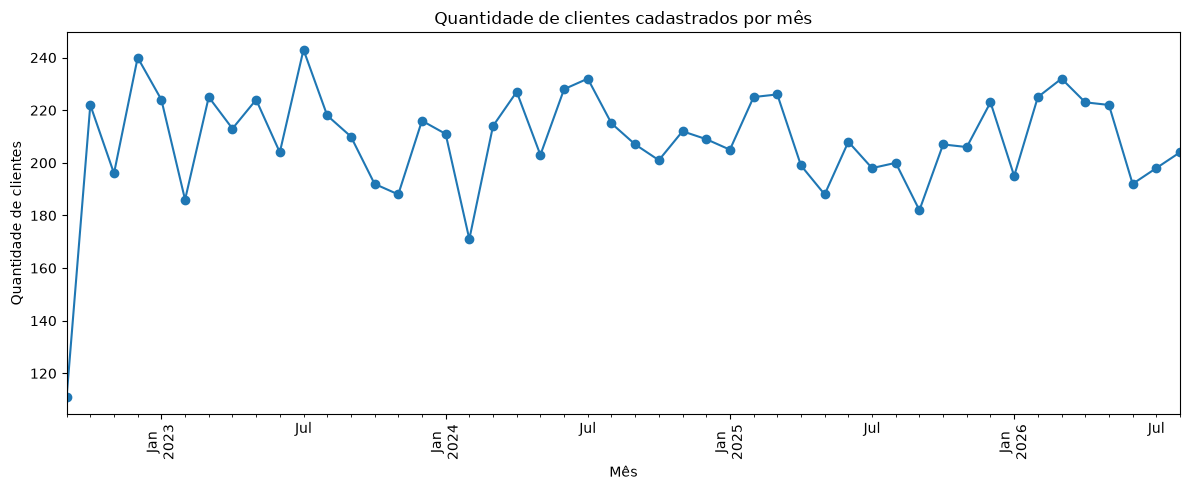

In [15]:
# --------------------------------------------------
# GRÁFICO DE CLIENTES CADASTRADOS POR MÊS
# --------------------------------------------------

# Importa biblioteca de gráficos
import matplotlib.pyplot as plt


# Define tamanho da figura
plt.figure(figsize=(12, 5))


# Cria gráfico de linha
clientes_por_mes.plot(
    marker="o"
)


# Título do gráfico
plt.title(
    "Quantidade de clientes cadastrados por mês"
)


# Nome do eixo X
plt.xlabel(
    "Mês"
)


# Nome do eixo Y
plt.ylabel(
    "Quantidade de clientes"
)


# Ajusta rotação dos meses
plt.xticks(
    rotation=90
)


# Ajusta espaçamento
plt.tight_layout()


# Exibe o gráfico
plt.show()

## Análise da evolução de clientes

Foi analisada a quantidade de clientes cadastrados mensalmente entre setembro de 2022 e agosto de 2026.

Observações:

- A aquisição de clientes apresenta comportamento estável ao longo do período.
- A quantidade mensal de novos clientes permaneceu aproximadamente entre 170 e 240 registros.
- Não foram identificados períodos com variações extremas de crescimento ou queda.

Essa análise permite compreender a evolução da base de clientes do e-commerce.

In [16]:
# --------------------------------------------------
# CRIAR ANO DE CADASTRO
# --------------------------------------------------

# Extrai apenas o ano da data de cadastro.

df_clientes["ano_cadastro"] = (
    df_clientes["dt_cadastro"]
    .dt
    .year
)


# Mostra exemplos

df_clientes[
    [
        "dt_cadastro",
        "ano_cadastro"
    ]
].head()

,dt_cadastro,ano_cadastro
0,2022-12-14 14:15:14,2022
1,2023-08-15 06:02:12,2023
2,2025-06-18 11:50:32,2025
3,2024-01-17 21:21:15,2024
4,2024-12-24 04:48:31,2024


In [17]:
# --------------------------------------------------
# CLIENTES CADASTRADOS POR ANO
# --------------------------------------------------

# Agrupa os clientes pelo ano de cadastro
# e conta a quantidade de registros.

clientes_por_ano = (
    df_clientes
    .groupby("ano_cadastro")
    .size()
)


# Exibe o resultado

clientes_por_ano

ano_cadastro
2022     769
2023    2543
2024    2530
2025    2467
2026    1691
dtype: int64

## Análise anual de novos clientes

Foi analisada a quantidade de novos clientes cadastrados por ano.

Resultados:

- 2023 apresentou o maior volume de novos clientes, com 2.543 registros.
- Entre 2023 e 2025, a aquisição anual permaneceu estável, variando entre aproximadamente 2,4 mil e 2,5 mil clientes.
- O ano de 2026 apresenta volume inferior, porém o período analisado ainda não contempla o ano completo.

A análise indica uma base de clientes com crescimento consistente ao longo do período.

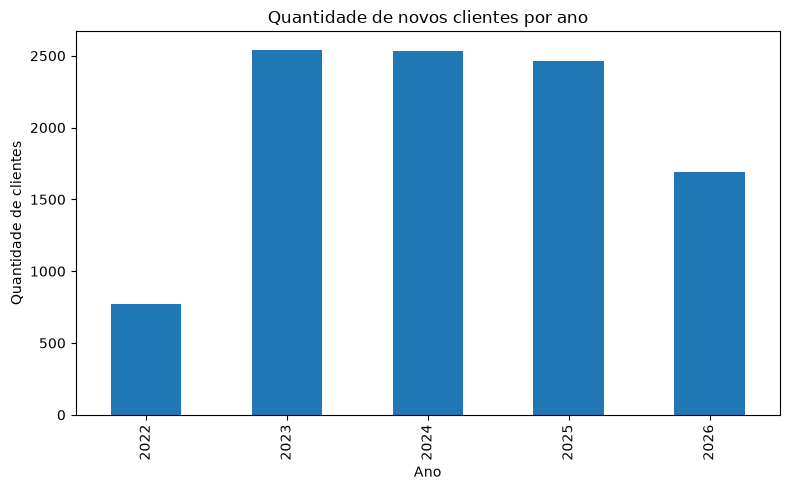

In [18]:
# --------------------------------------------------
# GRÁFICO DE CLIENTES POR ANO
# --------------------------------------------------

# Cria o tamanho da figura

plt.figure(figsize=(8,5))


# Cria gráfico de barras

clientes_por_ano.plot(
    kind="bar"
)


# Título

plt.title(
    "Quantidade de novos clientes por ano"
)


# Nome do eixo X

plt.xlabel(
    "Ano"
)


# Nome do eixo Y

plt.ylabel(
    "Quantidade de clientes"
)


# Ajusta layout

plt.tight_layout()


# Mostra gráfico

plt.show()

## Análise anual de novos clientes

A análise da quantidade de novos clientes por ano mostra:

- 2022 apresenta um volume menor de cadastros devido ao início do período analisado.
- Entre 2023 e 2025, a quantidade anual de novos clientes permaneceu estável, com aproximadamente 2,5 mil novos registros por ano.
- O ano de 2026 apresenta volume parcial, pois os dados disponíveis abrangem apenas até agosto.

O comportamento indica uma evolução consistente da base de clientes ao longo do período analisado.

In [19]:
# --------------------------------------------------
# ANÁLISE DE EMAILS DUPLICADOS
# --------------------------------------------------

# Conta quantos emails únicos existem

emails_unicos = (
    df_clientes["email"]
    .nunique()
)


# Quantidade total de clientes

total_clientes = (
    df_clientes.shape[0]
)


print(
    "Total de clientes:"
)

print(
    total_clientes
)


print(
    "\nQuantidade de emails únicos:"
)

print(
    emails_unicos
)


print(
    "\nDiferença:"
)

print(
    total_clientes - emails_unicos
)

Total de clientes:
10000

Quantidade de emails únicos:
10000

Diferença:
0


## Análise de unicidade de emails

Foi realizada uma análise para verificar a existência de emails duplicados na tabela `ecommerce_clientes`.

Resultados:

- Total de clientes analisados: 10.000
- Quantidade de emails únicos: 10.000
- Diferença encontrada: 0

Conclusão:

Todos os clientes possuem emails únicos, indicando consistência no cadastro dos usuários.

In [20]:
# --------------------------------------------------
# EXTRAIR DOMÍNIO DOS EMAILS
# --------------------------------------------------

# Cria uma nova coluna contendo apenas
# o domínio do email.
#
# Exemplo:
#
# joao@gmail.com
#
# vira:
#
# gmail.com

df_clientes["email_dominio"] = (
    df_clientes["email"]
    .str
    .split("@")
    .str[1]
)


# Visualizar alguns exemplos

df_clientes[
    [
        "email",
        "email_dominio"
    ]
].head()

,email,email_dominio
0,b_aragao@gmail.com,gmail.com
1,elisa.moura28@gmail.com,gmail.com
2,l.camara1995@gmail.com,gmail.com
3,dom.fonseca5@hotmail.com,hotmail.com
4,cavalcante_theo@hotmail.com,hotmail.com


In [21]:
# --------------------------------------------------
# TOP DOMÍNIOS DE EMAIL
# --------------------------------------------------

# Conta quantos clientes existem
# em cada domínio de email.

dominios_email = (
    df_clientes["email_dominio"]
    .value_counts()
)


# Mostra os 10 domínios mais utilizados.

dominios_email.head(10)

email_dominio
gmail.com       4506
hotmail.com     2501
outlook.com     1968
yahoo.com.br     508
uol.com.br       394
live.com         123
Name: count, dtype: int64

## Análise dos domínios de email

Foi realizada uma análise dos provedores de email utilizados pelos clientes.

Principais resultados:

- O domínio mais utilizado é `gmail.com`, com 4.506 clientes.
- Domínios Microsoft (`hotmail.com`, `outlook.com` e `live.com`) também apresentam grande participação.
- A maior parte dos clientes está concentrada em poucos provedores de email.

Essa análise ajuda a compreender o perfil de contato dos usuários cadastrados.

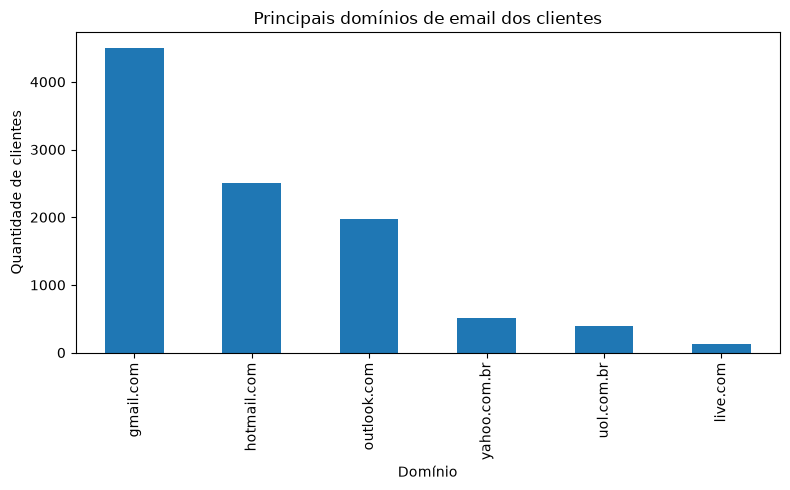

In [22]:
# --------------------------------------------------
# GRÁFICO DOS PRINCIPAIS DOMÍNIOS DE EMAIL
# --------------------------------------------------

# Seleciona os 6 maiores domínios
top_dominios = dominios_email.head(6)


# Define tamanho do gráfico

plt.figure(figsize=(8,5))


# Cria gráfico de barras

top_dominios.plot(
    kind="bar"
)


# Título

plt.title(
    "Principais domínios de email dos clientes"
)


# Nome do eixo X

plt.xlabel(
    "Domínio"
)


# Nome do eixo Y

plt.ylabel(
    "Quantidade de clientes"
)


# Ajusta layout

plt.tight_layout()


# Exibe gráfico

plt.show()

In [23]:
# --------------------------------------------------
# CLIENTES MAIS ANTIGOS DA BASE
# --------------------------------------------------

# Ordena os clientes pela data de cadastro
# do mais antigo para o mais recente.

clientes_antigos = (
    df_clientes
    .sort_values(
        "dt_cadastro"
    )
    .head(10)
)


# Exibe os primeiros clientes cadastrados

clientes_antigos[
    [
        "id_cliente",
        "nome",
        "sobrenome",
        "email",
        "dt_cadastro"
    ]
]

,id_cliente,nome,sobrenome,email,dt_cadastro
4264,4265,Camila,Barbosa Costa,camila.c1985@gmail.com,2022-09-16 20:46:29
2457,2458,Lucas Gabriel,Carvalho Correia,correia_lucas1988@outlook.com,2022-09-17 04:56:41
8443,8444,Mathias,Castro,m.castro84@hotmail.com,2022-09-17 05:49:21
8706,8707,Rebeca,Viana de Peixoto,rebeca_p@outlook.com,2022-09-17 08:58:25
45,46,Caroline,Machado Moreira,c_moreira@gmail.com,2022-09-17 09:40:57
6612,6613,Hadassa,Peixoto da Azevedo,azevedo_hadassa@gmail.com,2022-09-17 10:15:44
2578,2579,Yago,Melo Brito,yagob1987@outlook.com,2022-09-17 11:55:21
5626,5627,Eloah,Monteiro Câmara,eloahc1991@gmail.com,2022-09-17 13:37:25
4525,4526,Luana,Araújo Vieira,luana.vieira20@gmail.com,2022-09-17 14:11:44
7913,7914,Antônio,Cirino Barbosa,a_barbosa@yahoo.com.br,2022-09-17 16:23:23


In [24]:
# --------------------------------------------------
# CLIENTES MAIS RECENTES DA BASE
# --------------------------------------------------

# Ordena pela data de cadastro
# do mais recente para o mais antigo.

clientes_recentes = (
    df_clientes
    .sort_values(
        "dt_cadastro",
        ascending=False
    )
    .head(10)
)


# Exibe os últimos clientes cadastrados

clientes_recentes[
    [
        "id_cliente",
        "nome",
        "sobrenome",
        "email",
        "dt_cadastro"
    ]
]

,id_cliente,nome,sobrenome,email,dt_cadastro
5988,5989,Cecília,Cavalcanti Costa,costa_cecilia4@gmail.com,2026-08-27 20:47:09
5655,5656,Júlia,Fernandes Machado,j_machado@gmail.com,2026-08-27 15:51:22
8253,8254,Maria Flor,Vieira Carvalho,maria.c@outlook.com,2026-08-27 11:52:06
6383,6384,Maria Liz,Novais Mendes Correia,m_correia2001@gmail.com,2026-08-27 09:51:40
7253,7254,Benjamin,Nogueira do da Rocha,rocha_benjamin77@gmail.com,2026-08-27 09:49:33
5024,5025,Miguel,Pimenta,miguelp@hotmail.com,2026-08-27 08:34:13
406,407,Maysa,Leão da Mota,maysamota@gmail.com,2026-08-26 09:07:37
1037,1038,Eloá,Correia Marques,eloamarques@gmail.com,2026-08-26 07:29:04
5901,5902,Maria Vitória,Correia Martins Pires,m.pires@hotmail.com,2026-08-26 00:58:29
4904,4905,Benicio,Vasconcelos do Gomes,b.gomes80@hotmail.com,2026-08-25 20:06:40


## Clientes mais antigos e recentes

Foi realizada uma análise temporal da base de clientes utilizando a coluna `dt_cadastro`.

Resultados:

- Primeiro cadastro identificado: 16/09/2022 20:46:29.
- Último cadastro identificado: 27/08/2026 20:47:09.

Observação:

A coluna `id_cliente` não representa a ordem cronológica dos cadastros. Para análises históricas, a coluna `dt_cadastro` deve ser utilizada como referência.

# 2. Carregamento da tabela ecommerce_pedidos

Após estabelecer a conexão com o Azure Data Lake Storage Gen2, foi realizada a leitura da tabela sob responsabilidade da Squad 2.

## Tabela analisada

Tabela:
`ecommerce_pedidos`

## Tabela analisada

Tabela:

`ecommerce_pedidos`

Arquivo de origem:



## Tabela analisada

Tabela:

`ecommerce_pedidos`

Arquivo de origem:


In [25]:
# --------------------------------------------------
# CARREGAR TABELA ECOMMERCE_PEDIDOS
# --------------------------------------------------

# Caminho do arquivo dentro do Data Lake

arquivo_pedidos = (
    "batch-data/ecommerce_pedidos.csv"
)



# Criar cliente para acessar o arquivo

file_client = file_system_client.get_file_client(
    arquivo_pedidos
)



# Baixar o arquivo

download = file_client.download_file()



# Converter conteúdo para texto

conteudo = download.readall().decode(
    "utf-8"
)



# Criar DataFrame com pandas

df_pedidos = pd.read_csv(
    StringIO(conteudo)
)



# Confirmar carregamento

print(
    "Tabela ecommerce_pedidos carregada!"
)


print(
    "Quantidade de registros:"
)


print(
    df_pedidos.shape
)

Tabela ecommerce_pedidos carregada!
Quantidade de registros:
(90335, 10)


In [26]:
df_pedidos.head()


,id_pedido,id_cliente,id_endereco_entrega,dt_pedido,status_pedido,valor_total,valor_frete,metodo_pagamento,dt_previsao_entrega,dt_ultima_atualizacao_status
0,1,7374,7705,2025-12-04 08:00:59,Enviado,149.22,7.06,Cartão de Crédito,2025-12-09 08:00:59,2025-12-10 08:00:59
1,2,5556,5805,2025-02-08 21:55:31,Enviado,491.34,0.00,Cartão de Crédito,2025-02-13 21:55:31,2025-02-17 21:55:31
2,3,4910,5135,2024-06-02 12:33:15,Cancelado,672.53,0.00,Boleto,2024-06-09 12:33:15,2024-06-02 12:33:15
3,4,9544,9960,2025-11-08 23:23:06,Entregue,411.10,0.00,Pix,2025-11-16 23:23:06,2025-11-10 23:23:06
4,5,4575,4787,2024-11-06 01:21:51,Entregue,1659.51,0.00,Cartão de Crédito,2024-11-14 01:21:51,2024-11-08 01:21:51


# 3. Análise da estrutura da tabela (Schema)

Nesta etapa é realizada a análise da estrutura da tabela `ecommerce_pedidos`.

O objetivo é identificar:

- quantidade de registros;
- quantidade de colunas;
- tipos de dados;
- quantidade de valores preenchidos em cada coluna.

Essa análise permite compreender a organização dos dados antes da realização dos tratamentos e análises exploratórias.

In [27]:
# Visualização do schema da tabela

df_pedidos.info()

<class 'pandas.DataFrame'>
RangeIndex: 90335 entries, 0 to 90334
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_pedido                     90335 non-null  int64  
 1   id_cliente                    90335 non-null  int64  
 2   id_endereco_entrega           90335 non-null  int64  
 3   dt_pedido                     90335 non-null  str    
 4   status_pedido                 90335 non-null  str    
 5   valor_total                   90335 non-null  float64
 6   valor_frete                   90335 non-null  float64
 7   metodo_pagamento              90335 non-null  str    
 8   dt_previsao_entrega           90335 non-null  str    
 9   dt_ultima_atualizacao_status  90335 non-null  str    
dtypes: float64(2), int64(3), str(5)
memory usage: 6.9 MB


# 4. Análise de qualidade dos dados

Nesta etapa é realizada a verificação da qualidade da tabela `ecommerce_pedidos`, analisando a existência de valores ausentes.

A identificação de valores nulos é importante para garantir a confiabilidade das análises realizadas posteriormente.

Será verificada a quantidade de registros vazios em cada coluna da tabela.

In [28]:
df_pedidos.isnull().sum()

id_pedido                       0
id_cliente                      0
id_endereco_entrega             0
dt_pedido                       0
status_pedido                   0
valor_total                     0
valor_frete                     0
metodo_pagamento                0
dt_previsao_entrega             0
dt_ultima_atualizacao_status    0
dtype: int64

## Resultado

A análise identificou que todas as colunas possuem valores preenchidos.

Não foram encontrados valores nulos na tabela `ecommerce_pedidos`, indicando consistência inicial dos dados carregados.

In [29]:
# --------------------------------------------------
# VERIFICAÇÃO DE REGISTROS DUPLICADOS
# --------------------------------------------------

# Conta quantas linhas completamente
# duplicadas existem na tabela de pedidos.

df_pedidos.duplicated().sum()

np.int64(0)

## Resultado da análise de duplicidade

A análise identificou a quantidade de registros duplicados presentes na tabela `ecommerce_pedidos`.

Resultado:

- Quantidade de registros duplicados: 0

Conclusão:

Não foram encontrados registros duplicados na tabela analisada, garantindo maior confiabilidade para as métricas de pedidos e faturamento.

In [30]:
# --------------------------------------------------
# CONVERSÃO DAS DATAS DOS PEDIDOS
# --------------------------------------------------

# Converte a data do pedido

df_pedidos["dt_pedido"] = pd.to_datetime(
    df_pedidos["dt_pedido"]
)


# Converte a previsão de entrega

df_pedidos["dt_previsao_entrega"] = pd.to_datetime(
    df_pedidos["dt_previsao_entrega"]
)


# Converte a última atualização do status

df_pedidos["dt_ultima_atualizacao_status"] = pd.to_datetime(
    df_pedidos["dt_ultima_atualizacao_status"]
)


# Conferir os tipos novamente

df_pedidos.info()

<class 'pandas.DataFrame'>
RangeIndex: 90335 entries, 0 to 90334
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   id_pedido                     90335 non-null  int64         
 1   id_cliente                    90335 non-null  int64         
 2   id_endereco_entrega           90335 non-null  int64         
 3   dt_pedido                     90335 non-null  datetime64[us]
 4   status_pedido                 90335 non-null  str           
 5   valor_total                   90335 non-null  float64       
 6   valor_frete                   90335 non-null  float64       
 7   metodo_pagamento              90335 non-null  str           
 8   dt_previsao_entrega           90335 non-null  datetime64[us]
 9   dt_ultima_atualizacao_status  90335 non-null  datetime64[us]
dtypes: datetime64[us](3), float64(2), int64(3), str(2)
memory usage: 6.9 MB


In [31]:
# --------------------------------------------------
# PERÍODO DOS PEDIDOS
# --------------------------------------------------

# Primeiro pedido realizado

primeiro_pedido = (
    df_pedidos["dt_pedido"]
    .min()
)


# Último pedido realizado

ultimo_pedido = (
    df_pedidos["dt_pedido"]
    .max()
)



print(
    "Primeiro pedido:"
)

print(
    primeiro_pedido
)



print(
    "\nÚltimo pedido:"
)

print(
    ultimo_pedido
)

Primeiro pedido:
2024-01-01 02:44:59

Último pedido:
2026-08-31 23:50:50


# 6. Análise do período dos pedidos

Nesta etapa é realizada a análise temporal da tabela `ecommerce_pedidos`.

O objetivo é identificar o intervalo de datas disponível na base, verificando:

- data do primeiro pedido registrado;
- data do último pedido registrado.

Essa análise permite compreender o período histórico disponível para as análises de vendas e comportamento dos pedidos.

## Resultado da análise temporal

A tabela `ecommerce_pedidos` possui registros de pedidos realizados entre:

- Primeiro pedido: 01/01/2024
- Último pedido: 31/08/2026

O período analisado contempla aproximadamente 2 anos e 8 meses de histórico de pedidos.

In [32]:
# --------------------------------------------------
# CRIAR MÊS DO PEDIDO
# --------------------------------------------------

# Extrai ano e mês da data do pedido.

df_pedidos["mes_pedido"] = (
    df_pedidos["dt_pedido"]
    .dt
    .to_period("M")
)


# Visualizar exemplos

df_pedidos[
    [
        "dt_pedido",
        "mes_pedido"
    ]
].head()

,dt_pedido,mes_pedido
0,2025-12-04 08:00:59,2025-12
1,2025-02-08 21:55:31,2025-02
2,2024-06-02 12:33:15,2024-06
3,2025-11-08 23:23:06,2025-11
4,2024-11-06 01:21:51,2024-11


In [33]:
# --------------------------------------------------
# PEDIDOS POR MÊS
# --------------------------------------------------

# Agrupa os pedidos pelo mês
# e conta a quantidade de pedidos.

pedidos_por_mes = (
    df_pedidos
    .groupby("mes_pedido")
    .size()
)


# Exibe o resultado

pedidos_por_mes


mes_pedido
2024-01    2470
2024-02    1910
2024-03    2862
2024-04    2537
2024-05    3225
2024-06    2587
2024-07    2502
2024-08    2927
2024-09    2526
2024-10    3104
2024-11    3673
2024-12    4506
2025-01    2537
2025-02    1721
2025-03    2685
2025-04    2551
2025-05    3230
2025-06    2623
2025-07    2507
2025-08    2869
2025-09    2606
2025-10    3258
2025-11    3382
2025-12    4708
2026-01    2684
2026-02    1757
2026-03    2746
2026-04    2630
2026-05    3149
2026-06    2524
2026-07    2595
2026-08    2744
Freq: M, dtype: int64

## Resultado da análise de pedidos por mês

A análise da quantidade de pedidos ao longo do tempo apresentou variações mensais no volume de vendas.

Observações:

- O volume de pedidos apresentou comportamento variável durante o período analisado.
- Os maiores volumes foram observados próximos ao final dos anos analisados.
- O mês de dezembro apresentou maior concentração de pedidos, indicando possível comportamento sazonal.

Essa análise permite compreender a evolução da demanda do e-commerce.

## Evolução mensal de pedidos

Foi analisada a quantidade de pedidos realizados por mês utilizando a coluna `dt_pedido`.

Observações:

- O volume mensal apresenta variações ao longo do período.
- Os maiores volumes de pedidos ocorreram próximos ao final dos anos analisados.
- Dezembro apresentou valores elevados em relação a outros meses, sugerindo possível comportamento sazonal.

Essa análise ajuda a compreender a dinâmica de demanda do e-commerce.

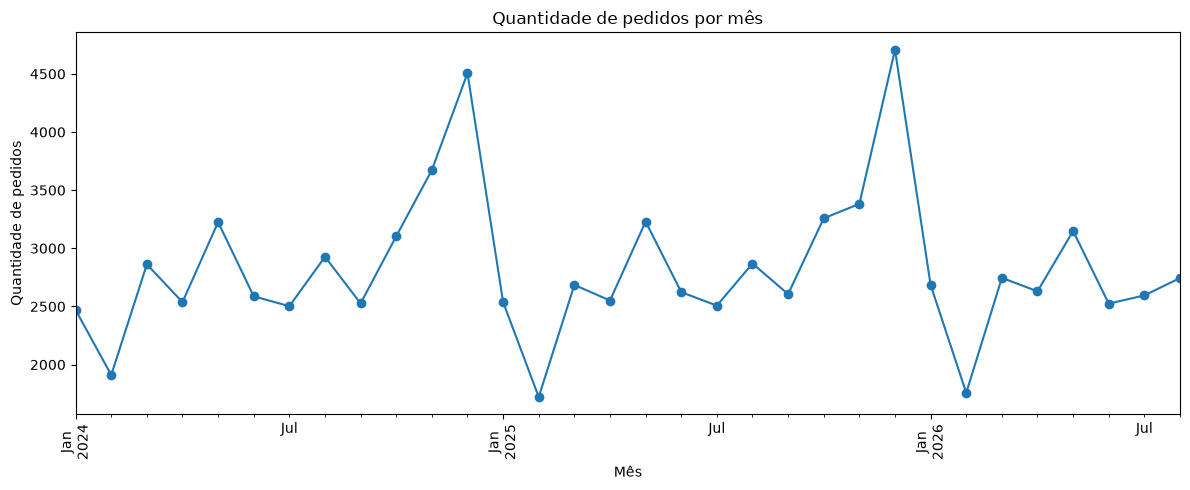

In [34]:
# --------------------------------------------------
# GRÁFICO DE PEDIDOS POR MÊS
# --------------------------------------------------

# Define o tamanho do gráfico

plt.figure(figsize=(12,5))


# Cria gráfico de linha

pedidos_por_mes.plot(
    marker="o"
)


# Título

plt.title(
    "Quantidade de pedidos por mês"
)


# Eixo X

plt.xlabel(
    "Mês"
)


# Eixo Y

plt.ylabel(
    "Quantidade de pedidos"
)


# Rotaciona os meses

plt.xticks(
    rotation=90
)


# Ajusta layout

plt.tight_layout()


# Exibe gráfico

plt.show()

## Evolução mensal de pedidos

Foi analisada a quantidade de pedidos realizados mensalmente utilizando a coluna `dt_pedido`.

Observações:

- O volume de pedidos apresenta variações ao longo do período analisado.
- Os maiores volumes ocorreram nos meses de dezembro de 2024 e dezembro de 2025.
- Existe uma possível sazonalidade de fim de ano, que deverá ser validada junto às métricas financeiras.

A análise permite compreender o comportamento da demanda do e-commerce.

In [35]:
# --------------------------------------------------
# FATURAMENTO POR MÊS
# --------------------------------------------------

# Soma o valor total dos pedidos
# agrupando por mês.

faturamento_por_mes = (
    df_pedidos
    .groupby("mes_pedido")["valor_total"]
    .sum()
)


# Exibe o resultado

faturamento_por_mes

mes_pedido
2024-01    2106983.27
2024-02    1590523.28
2024-03    2386503.91
2024-04    2178618.08
2024-05    2685740.70
2024-06    2155594.06
2024-07    2146273.57
2024-08    2453545.41
2024-09    2134290.16
2024-10    2645166.30
2024-11    3068002.08
2024-12    3852943.94
2025-01    2133373.89
2025-02    1429028.45
2025-03    2303056.82
2025-04    2157333.86
2025-05    2695948.71
2025-06    2188839.24
2025-07    2113084.94
2025-08    2396633.06
2025-09    2218707.24
2025-10    2738335.08
2025-11    2860263.54
2025-12    3990841.87
2026-01    2267025.69
2026-02    1459082.13
2026-03    2360688.83
2026-04    2164246.12
2026-05    2657904.42
2026-06    2087516.70
2026-07    2151618.87
2026-08    2289782.60
Freq: M, Name: valor_total, dtype: float64

## Resultado da análise de faturamento

A análise do faturamento mensal demonstrou variações na receita ao longo do período analisado.

Principais observações:

- O faturamento acompanha o comportamento do volume de pedidos.
- Os maiores valores de receita ocorreram em períodos próximos ao final dos anos analisados.
- Dezembro apresentou destaque no faturamento, indicando possível influência de sazonalidade.

A análise permite compreender a evolução financeira do e-commerce ao longo do tempo.

In [36]:
# --------------------------------------------------
# TICKET MÉDIO DOS PEDIDOS
# --------------------------------------------------

# Calcula o valor médio de cada pedido.

ticket_medio = (
    df_pedidos["valor_total"]
    .mean()
)


print(
    "Ticket médio por pedido:"
)


print(
    ticket_medio
)

Ticket médio por pedido:
842.0600743897713


## Resultado da análise de ticket médio

O ticket médio calculado para os pedidos foi:

**R$ 842,06 por pedido**

Esse indicador representa o valor médio gerado por cada compra realizada no e-commerce durante o período analisado.

A métrica auxilia na compreensão do comportamento de consumo e na avaliação do desempenho financeiro das vendas.

## Ticket médio dos pedidos

Foi calculado o ticket médio considerando o valor total de todos os pedidos.

Resultado:

- Quantidade de pedidos analisados: 90.335
- Ticket médio por pedido: aproximadamente R$ 842,06

O indicador representa o valor médio gerado por pedido realizado no e-commerce.

In [37]:
# --------------------------------------------------
# DISTRIBUIÇÃO DOS STATUS DOS PEDIDOS
# --------------------------------------------------

# Conta a quantidade de pedidos
# em cada status.

status_pedidos = (
    df_pedidos["status_pedido"]
    .value_counts()
)


# Exibe o resultado

status_pedidos

status_pedido
Entregue              54175
Enviado               13608
Em Separação           9007
Cancelado              4554
Pagamento Aprovado     4549
Processando            4442
Name: count, dtype: int64

## Resultado da análise de status

A distribuição dos pedidos por status apresentou o seguinte comportamento:

- A maior parte dos pedidos encontra-se como `Entregue`.
- Existem pedidos em diferentes etapas do fluxo operacional, como `Enviado`, `Em Separação` e `Processando`.
- Os pedidos com status `Cancelado` representam uma parcela menor do total analisado.

A análise permite compreender o estágio operacional dos pedidos dentro do processo de venda.

In [38]:
# --------------------------------------------------
# TAXA DE CANCELAMENTO
# --------------------------------------------------

# Quantidade total de pedidos

total_pedidos = (
    df_pedidos.shape[0]
)


# Quantidade de pedidos cancelados

pedidos_cancelados = (
    df_pedidos[
        df_pedidos["status_pedido"] == "Cancelado"
    ]
    .shape[0]
)


# Calcula percentual

taxa_cancelamento = (
    pedidos_cancelados / total_pedidos
) * 100



print(
    "Total de pedidos:"
)

print(
    total_pedidos
)


print(
    "\nPedidos cancelados:"
)

print(
    pedidos_cancelados
)


print(
    "\nTaxa de cancelamento:"
)

print(
    round(taxa_cancelamento, 2),
    "%"
)

Total de pedidos:
90335

Pedidos cancelados:
4554

Taxa de cancelamento:
5.04 %


## Taxa de cancelamento dos pedidos

Foi calculada a taxa de cancelamento dos pedidos utilizando a coluna `status_pedido`.

Resultados:

- Total de pedidos analisados: 90.335
- Pedidos cancelados: 4.554
- Taxa de cancelamento: 5,04%

A análise indica que uma pequena parcela dos pedidos foi cancelada em relação ao volume total processado.

In [39]:
# --------------------------------------------------
# MÉTODOS DE PAGAMENTO
# --------------------------------------------------

# Conta a quantidade de pedidos
# por método de pagamento.

metodos_pagamento = (
    df_pedidos["metodo_pagamento"]
    .value_counts()
)


# Exibe o resultado

metodos_pagamento

metodo_pagamento
Cartão de Crédito    58662
Pix                  27177
Boleto                4496
Name: count, dtype: int64

## Análise dos métodos de pagamento

Foi analisada a distribuição dos métodos de pagamento utilizados nos pedidos.

Resultados:

- O Cartão de Crédito é o método predominante, utilizado em 58.662 pedidos.
- O Pix representa uma parcela significativa das transações, com 27.177 pedidos.
- O Boleto apresenta menor participação entre os métodos analisados.

A análise indica predominância de pagamentos digitais no comportamento dos clientes.

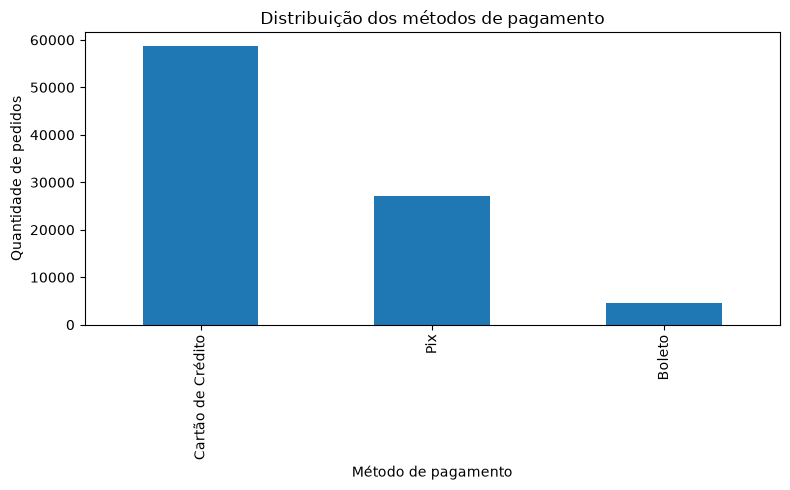

In [40]:
# --------------------------------------------------
# GRÁFICO DE MÉTODOS DE PAGAMENTO
# --------------------------------------------------

# Define tamanho do gráfico

plt.figure(figsize=(8,5))


# Cria gráfico de barras

metodos_pagamento.plot(
    kind="bar"
)


# Título

plt.title(
    "Distribuição dos métodos de pagamento"
)


# Eixo X

plt.xlabel(
    "Método de pagamento"
)


# Eixo Y

plt.ylabel(
    "Quantidade de pedidos"
)


# Ajusta layout

plt.tight_layout()


# Exibe gráfico

plt.show()

## Análise dos métodos de pagamento

Foi analisada a distribuição dos métodos de pagamento utilizados nos pedidos.

Resultados:

- O Cartão de Crédito é o principal método, representando a maior parte das transações.
- O Pix apresenta participação significativa no volume de pedidos.
- O Boleto possui menor utilização entre os métodos analisados.

A análise indica predominância de métodos digitais de pagamento no e-commerce.

In [41]:
# --------------------------------------------------
# FATURAMENTO POR MÉTODO DE PAGAMENTO
# --------------------------------------------------

# Soma o valor total dos pedidos
# agrupando pelo método de pagamento.

faturamento_pagamento = (
    df_pedidos
    .groupby("metodo_pagamento")["valor_total"]
    .sum()
)


# Exibe o resultado

faturamento_pagamento

metodo_pagamento
Boleto                3733345.47
Cartão de Crédito    49410613.01
Pix                  22923538.34
Name: valor_total, dtype: float64

In [42]:
# --------------------------------------------------
# PARTICIPAÇÃO DO FATURAMENTO POR PAGAMENTO
# --------------------------------------------------

# Soma total do faturamento

faturamento_total = (
    faturamento_pagamento.sum()
)


# Calcula o percentual de participação

participacao_pagamento = (
    faturamento_pagamento / faturamento_total
) * 100


# Ordena do maior para o menor

participacao_pagamento.sort_values(
    ascending=False
)

metodo_pagamento
Cartão de Crédito    64.956276
Pix                  30.135786
Boleto                4.907938
Name: valor_total, dtype: float64

## Participação do faturamento por método de pagamento

Foi analisada a participação percentual da receita gerada por cada método de pagamento.

Resultados:

- Cartão de Crédito representa aproximadamente 64,96% do faturamento.
- Pix representa aproximadamente 30,14% da receita.
- Boleto representa aproximadamente 4,91%.

O faturamento do e-commerce está concentrado principalmente em pagamentos digitais, com predominância do Cartão de Crédito e participação relevante do Pix.

In [43]:
# --------------------------------------------------
# CLIENTES COM MAIOR FATURAMENTO
# --------------------------------------------------

# Soma o valor total dos pedidos
# agrupando por cliente.

clientes_faturamento = (
    df_pedidos
    .groupby("id_cliente")["valor_total"]
    .sum()
    .sort_values(
        ascending=False
    )
)


# Mostra os 10 clientes
# com maior faturamento gerado.

clientes_faturamento.head(10)

id_cliente
1403    21073.50
7559    20685.51
8257    19784.85
2485    19410.27
9519    19089.71
7338    19013.61
7340    18824.25
126     18800.86
3846    18728.38
5166    18526.40
Name: valor_total, dtype: float64

In [44]:
# --------------------------------------------------
# CRUZAMENTO CLIENTES + PEDIDOS
# --------------------------------------------------

# Transforma a série de faturamento
# em um DataFrame.

clientes_valor = (
    clientes_faturamento
    .reset_index()
)


# Renomeia a coluna de valor

clientes_valor.columns = [
    "id_cliente",
    "valor_total_compras"
]



# Junta com a tabela de clientes

clientes_valor = clientes_valor.merge(
    df_clientes[
        [
            "id_cliente",
            "nome",
            "sobrenome",
            "email"
        ]
    ],
    on="id_cliente",
    how="left"
)



# Ordena pelos maiores compradores

clientes_valor.head(10)

,id_cliente,valor_total_compras,nome,sobrenome,email
0,1403,21073.50,Caroline,Câmara da Macedo,c.macedo@outlook.com
1,7559,20685.51,Lívia,da Cruz Gomes,livia.gomes64@gmail.com
2,8257,19784.85,Ana Liz,Silveira Abreu,a_abreu1991@gmail.com
3,2485,19410.27,Isis,Siqueira Monteiro,isis_monteiro2001@gmail.com
4,9519,19089.71,Maria Liz,Fogaça do da Luz,luz.maria@outlook.com
5,7338,19013.61,Ana Clara,Vieira,a_vieira34@gmail.com
6,7340,18824.25,Bernardo,da Paz da Conceição,bconceicao@gmail.com
7,126,18800.86,Antony,Machado Rodrigues,antony_rodrigues@hotmail.com
8,3846,18728.38,Isaque,Casa Grande dos Souza,isaques@gmail.com
9,5166,18526.40,Heloísa,Novais Costela,heloisa_c@hotmail.com


## Clientes com maior valor de compras

Foi realizada uma análise para identificar os clientes que geraram maior receita acumulada.

A análise foi feita através da soma do campo `valor_total` agrupado por `id_cliente`, posteriormente relacionado com os dados cadastrais dos clientes.

Principais observações:

- Os clientes de maior valor possuem compras acumuladas próximas ou superiores a R$ 20 mil.
- O cruzamento entre pedidos e clientes permite identificar usuários de maior relevância financeira para o negócio.

In [45]:
# --------------------------------------------------
# QUANTIDADE DE PEDIDOS POR CLIENTE
# --------------------------------------------------

# Conta quantos pedidos cada cliente realizou.

pedidos_por_cliente = (
    df_pedidos
    .groupby("id_cliente")
    .size()
    .sort_values(
        ascending=False
    )
)


# Mostra os 10 clientes
# com maior quantidade de pedidos.

pedidos_por_cliente.head(10)

id_cliente
7891    22
5166    21
3294    21
869     20
9519    20
6286    20
2813    20
9574    20
8873    20
6778    20
dtype: int64

In [46]:
# --------------------------------------------------
# VISÃO COMPLETA DOS CLIENTES
# --------------------------------------------------

# Transforma quantidade de pedidos em DataFrame

clientes_frequencia = (
    pedidos_por_cliente
    .reset_index()
)


# Renomeia as colunas

clientes_frequencia.columns = [
    "id_cliente",
    "quantidade_pedidos"
]



# Junta frequência com valor gasto

clientes_analise = clientes_valor.merge(
    clientes_frequencia,
    on="id_cliente",
    how="left"
)



# Ordena pelos maiores compradores

clientes_analise = (
    clientes_analise
    .sort_values(
        "valor_total_compras",
        ascending=False
    )
)



# Visualiza os primeiros

clientes_analise.head(10)

,id_cliente,valor_total_compras,nome,sobrenome,email,quantidade_pedidos
0,1403,21073.50,Caroline,Câmara da Macedo,c.macedo@outlook.com,17
1,7559,20685.51,Lívia,da Cruz Gomes,livia.gomes64@gmail.com,19
2,8257,19784.85,Ana Liz,Silveira Abreu,a_abreu1991@gmail.com,18
3,2485,19410.27,Isis,Siqueira Monteiro,isis_monteiro2001@gmail.com,18
4,9519,19089.71,Maria Liz,Fogaça do da Luz,luz.maria@outlook.com,20
5,7338,19013.61,Ana Clara,Vieira,a_vieira34@gmail.com,17
6,7340,18824.25,Bernardo,da Paz da Conceição,bconceicao@gmail.com,15
7,126,18800.86,Antony,Machado Rodrigues,antony_rodrigues@hotmail.com,20
8,3846,18728.38,Isaque,Casa Grande dos Souza,isaques@gmail.com,19
9,5166,18526.40,Heloísa,Novais Costela,heloisa_c@hotmail.com,21


In [47]:
# --------------------------------------------------
# MÉDIA DE COMPRA POR CLIENTE
# --------------------------------------------------

# Calcula o valor médio acumulado
# gasto por cliente.

media_cliente = (
    clientes_analise["valor_total_compras"]
    .mean()
)


print(
    "Média de gasto por cliente:"
)

print(
    media_cliente
)

Média de gasto por cliente:
7608.271336267253


In [48]:
# --------------------------------------------------
# SEGMENTAÇÃO DE CLIENTES POR VALOR
# --------------------------------------------------

# Define a média de gasto dos clientes

media_gasto = (
    clientes_analise["valor_total_compras"]
    .mean()
)


# Cria uma nova coluna de classificação

clientes_analise["segmento_valor"] = (
    clientes_analise["valor_total_compras"]
    .apply(
        lambda valor:
        "Alto Valor"
        if valor > media_gasto
        else "Valor Normal"
    )
)


# Visualizar alguns registros

clientes_analise.head()

,id_cliente,valor_total_compras,nome,sobrenome,email,quantidade_pedidos,segmento_valor
0,1403,21073.50,Caroline,Câmara da Macedo,c.macedo@outlook.com,17,Alto Valor
1,7559,20685.51,Lívia,da Cruz Gomes,livia.gomes64@gmail.com,19,Alto Valor
2,8257,19784.85,Ana Liz,Silveira Abreu,a_abreu1991@gmail.com,18,Alto Valor
3,2485,19410.27,Isis,Siqueira Monteiro,isis_monteiro2001@gmail.com,18,Alto Valor
4,9519,19089.71,Maria Liz,Fogaça do da Luz,luz.maria@outlook.com,20,Alto Valor


In [49]:
# --------------------------------------------------
# QUANTIDADE DE CLIENTES POR SEGMENTO
# --------------------------------------------------

# Conta quantos clientes existem
# em cada grupo.

segmentos_clientes = (
    clientes_analise["segmento_valor"]
    .value_counts()
)


# Exibe o resultado

segmentos_clientes

segmento_valor
Valor Normal    5320
Alto Valor      4678
Name: count, dtype: int64

## Segmentação de clientes por valor

Foi criada uma segmentação simples baseada no valor total acumulado de compras.

Critério utilizado:

- Alto Valor: clientes com gasto superior ao gasto médio da base.
- Valor Normal: clientes com gasto igual ou inferior à média.

Resultados:

- Alto Valor: 4.678 clientes.
- Valor Normal: 5.320 clientes.

A segmentação permite identificar grupos de clientes com diferentes níveis de contribuição financeira para o e-commerce.

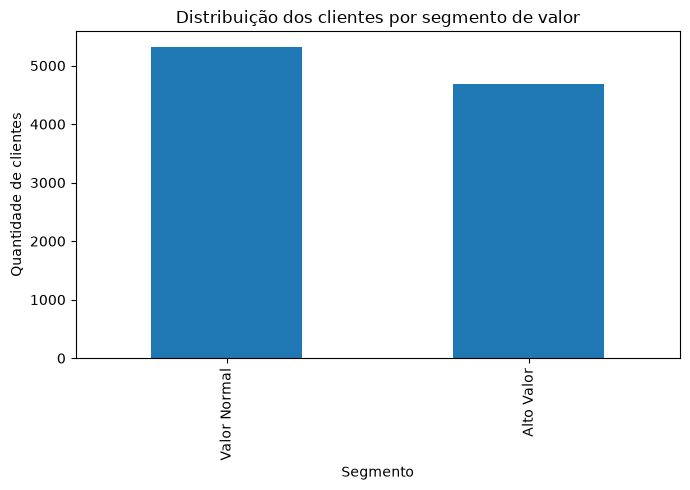

In [50]:
# --------------------------------------------------
# GRÁFICO DE SEGMENTAÇÃO DE CLIENTES
# --------------------------------------------------

# Define tamanho do gráfico

plt.figure(figsize=(7,5))


# Cria gráfico de barras

segmentos_clientes.plot(
    kind="bar"
)


# Título

plt.title(
    "Distribuição dos clientes por segmento de valor"
)


# Eixo X

plt.xlabel(
    "Segmento"
)


# Eixo Y

plt.ylabel(
    "Quantidade de clientes"
)


# Ajusta layout

plt.tight_layout()


# Exibe gráfico

plt.show()

In [51]:
# --------------------------------------------------
# ÚLTIMA COMPRA POR CLIENTE
# --------------------------------------------------

# Obtém a data do último pedido
# realizado por cada cliente.

ultima_compra = (
    df_pedidos
    .groupby("id_cliente")["dt_pedido"]
    .max()
)


# Mostra exemplos

ultima_compra.head()

id_cliente
1   2026-05-23 13:26:01
2   2025-04-20 23:12:07
3   2026-08-20 19:50:30
4   2026-08-29 21:21:49
5   2026-04-02 09:23:16
Name: dt_pedido, dtype: datetime64[us]

In [52]:
# --------------------------------------------------
# CRIAÇÃO DA TABELA RFM
# --------------------------------------------------

# Transformar última compra em DataFrame

rfm = (
    ultima_compra
    .reset_index()
)


# Renomear coluna

rfm.columns = [
    "id_cliente",
    "ultima_compra"
]



# Adicionar quantidade de pedidos

rfm = rfm.merge(
    pedidos_por_cliente.reset_index(
    name="quantidade_pedidos"
    ),
    on="id_cliente",
    how="left"
)



# Adicionar valor total comprado

rfm = rfm.merge(
    clientes_valor[
        [
            "id_cliente",
            "valor_total_compras"
        ]
    ],
    on="id_cliente",
    how="left"
)



# Mostrar resultado

rfm.head()

,id_cliente,ultima_compra,quantidade_pedidos,valor_total_compras
0,1,2026-05-23 13:26:01,8,7219.49
1,2,2025-04-20 23:12:07,8,7008.95
2,3,2026-08-20 19:50:30,9,7085.21
3,4,2026-08-29 21:21:49,10,9197.41
4,5,2026-04-02 09:23:16,12,8843.46


In [53]:
# --------------------------------------------------
# RECÊNCIA EM DIAS
# --------------------------------------------------

# Define a data de referência da análise.
# Usaremos o último dia disponível da base.

data_referencia = (
    df_pedidos["dt_pedido"]
    .max()
)



# Calcula quantos dias passaram
# desde a última compra de cada cliente.

rfm["dias_desde_ultima_compra"] = (
    data_referencia
    -
    rfm["ultima_compra"]
).dt.days



# Visualizar resultado

rfm.head()

,id_cliente,ultima_compra,quantidade_pedidos,valor_total_compras,dias_desde_ultima_compra
0,1,2026-05-23 13:26:01,8,7219.49,100
1,2,2025-04-20 23:12:07,8,7008.95,498
2,3,2026-08-20 19:50:30,9,7085.21,11
3,4,2026-08-29 21:21:49,10,9197.41,2
4,5,2026-04-02 09:23:16,12,8843.46,151


In [54]:
# --------------------------------------------------
# SEGMENTAÇÃO DE ATIVIDADE DOS CLIENTES
# --------------------------------------------------

# Cria uma classificação simples
# baseada no tempo desde a última compra.

def classificar_cliente(dias):

    if dias <= 90:
        return "Cliente Ativo"

    elif dias <= 365:
        return "Cliente Ocasional"

    else:
        return "Cliente Inativo"



# Aplica a classificação

rfm["segmento_atividade"] = (
    rfm["dias_desde_ultima_compra"]
    .apply(classificar_cliente)
)



# Visualizar resultado

rfm.head()

,id_cliente,ultima_compra,quantidade_pedidos,valor_total_compras,dias_desde_ultima_compra,segmento_atividade
0,1,2026-05-23 13:26:01,8,7219.49,100,Cliente Ocasional
1,2,2025-04-20 23:12:07,8,7008.95,498,Cliente Inativo
2,3,2026-08-20 19:50:30,9,7085.21,11,Cliente Ativo
3,4,2026-08-29 21:21:49,10,9197.41,2,Cliente Ativo
4,5,2026-04-02 09:23:16,12,8843.46,151,Cliente Ocasional


In [55]:
# --------------------------------------------------
# QUANTIDADE DE CLIENTES POR SEGMENTO
# --------------------------------------------------

# Conta quantos clientes existem
# em cada segmento.

segmentos_rfm = (
    rfm["segmento_atividade"]
    .value_counts()
)


# Exibe resultado

segmentos_rfm

segmento_atividade
Cliente Ativo        5386
Cliente Ocasional    4285
Cliente Inativo       327
Name: count, dtype: int64

## Segmentação RFM simplificada

Foi criada uma segmentação dos clientes baseada no tempo desde a última compra.

Critérios:

- Cliente Ativo: última compra realizada nos últimos 90 dias.
- Cliente Ocasional: última compra entre 91 e 365 dias.
- Cliente Inativo: sem compras há mais de 365 dias.

Resultados:

- Clientes Ativos: 5.386
- Clientes Ocasionais: 4.285
- Clientes Inativos: 327

A análise permite identificar o nível de engajamento dos clientes e apoiar estratégias de relacionamento.

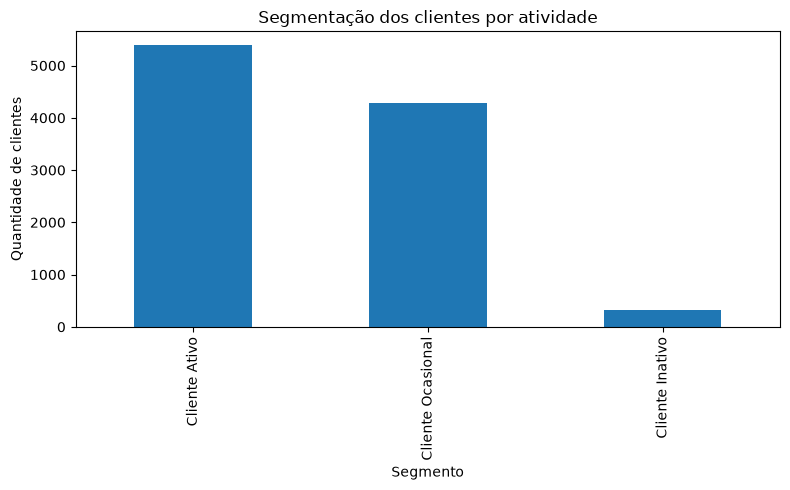

In [56]:
# --------------------------------------------------
# GRÁFICO DE SEGMENTAÇÃO RFM
# --------------------------------------------------

# Define tamanho do gráfico

plt.figure(figsize=(8,5))


# Cria gráfico de barras

segmentos_rfm.plot(
    kind="bar"
)


# Título

plt.title(
    "Segmentação dos clientes por atividade"
)


# Eixo X

plt.xlabel(
    "Segmento"
)


# Eixo Y

plt.ylabel(
    "Quantidade de clientes"
)


# Ajusta layout

plt.tight_layout()


# Exibe gráfico

plt.show()

In [57]:
# --------------------------------------------------
# TABELA FINAL RFM PARA ENTREGA
# --------------------------------------------------

clientes_rfm_final = rfm[
    [
        "id_cliente",
        "ultima_compra",
        "dias_desde_ultima_compra",
        "quantidade_pedidos",
        "valor_total_compras",
        "segmento_atividade"
    ]
]


# Visualizar

clientes_rfm_final.head()

,id_cliente,ultima_compra,dias_desde_ultima_compra,quantidade_pedidos,valor_total_compras,segmento_atividade
0,1,2026-05-23 13:26:01,100,8,7219.49,Cliente Ocasional
1,2,2025-04-20 23:12:07,498,8,7008.95,Cliente Inativo
2,3,2026-08-20 19:50:30,11,9,7085.21,Cliente Ativo
3,4,2026-08-29 21:21:49,2,10,9197.41,Cliente Ativo
4,5,2026-04-02 09:23:16,151,12,8843.46,Cliente Ocasional


In [58]:
# --------------------------------------------------
# PREPARAÇÃO PARA ENVIO AO SQL SERVER
# --------------------------------------------------

# Cria uma cópia da tabela final

df_sql_rfm = clientes_rfm_final.copy()


# Converte datas para texto no formato SQL

df_sql_rfm["ultima_compra"] = (
    df_sql_rfm["ultima_compra"]
    .dt
    .strftime("%Y-%m-%d %H:%M:%S")
)


# Visualizar

df_sql_rfm.head()

,id_cliente,ultima_compra,dias_desde_ultima_compra,quantidade_pedidos,valor_total_compras,segmento_atividade
0,1,2026-05-23 13:26:01,100,8,7219.49,Cliente Ocasional
1,2,2025-04-20 23:12:07,498,8,7008.95,Cliente Inativo
2,3,2026-08-20 19:50:30,11,9,7085.21,Cliente Ativo
3,4,2026-08-29 21:21:49,2,10,9197.41,Cliente Ativo
4,5,2026-04-02 09:23:16,151,12,8843.46,Cliente Ocasional


In [59]:
clientes_rfm_final.head()

,id_cliente,ultima_compra,dias_desde_ultima_compra,quantidade_pedidos,valor_total_compras,segmento_atividade
0,1,2026-05-23 13:26:01,100,8,7219.49,Cliente Ocasional
1,2,2025-04-20 23:12:07,498,8,7008.95,Cliente Inativo
2,3,2026-08-20 19:50:30,11,9,7085.21,Cliente Ativo
3,4,2026-08-29 21:21:49,2,10,9197.41,Cliente Ativo
4,5,2026-04-02 09:23:16,151,12,8843.46,Cliente Ocasional


In [60]:
df_pedidos.head()

,id_pedido,id_cliente,id_endereco_entrega,dt_pedido,status_pedido,valor_total,valor_frete,metodo_pagamento,dt_previsao_entrega,dt_ultima_atualizacao_status,mes_pedido
0,1,7374,7705,2025-12-04 08:00:59,Enviado,149.22,7.06,Cartão de Crédito,2025-12-09 08:00:59,2025-12-10 08:00:59,2025-12
1,2,5556,5805,2025-02-08 21:55:31,Enviado,491.34,0.00,Cartão de Crédito,2025-02-13 21:55:31,2025-02-17 21:55:31,2025-02
2,3,4910,5135,2024-06-02 12:33:15,Cancelado,672.53,0.00,Boleto,2024-06-09 12:33:15,2024-06-02 12:33:15,2024-06
3,4,9544,9960,2025-11-08 23:23:06,Entregue,411.10,0.00,Pix,2025-11-16 23:23:06,2025-11-10 23:23:06,2025-11
4,5,4575,4787,2024-11-06 01:21:51,Entregue,1659.51,0.00,Cartão de Crédito,2024-11-14 01:21:51,2024-11-08 01:21:51,2024-11


In [61]:
df_pedidos.columns

Index(['id_pedido', 'id_cliente', 'id_endereco_entrega', 'dt_pedido',
       'status_pedido', 'valor_total', 'valor_frete', 'metodo_pagamento',
       'dt_previsao_entrega', 'dt_ultima_atualizacao_status', 'mes_pedido'],
      dtype='str')

In [62]:
# --------------------------------------------------
# PREPARAR TABELA ORIGINAL PARA ENTREGA SQL
# --------------------------------------------------

# Remove a coluna criada apenas para análise

df_pedidos_sql = df_pedidos.drop(
    columns=["mes_pedido"]
)


# Conferir as colunas finais

df_pedidos_sql.columns

Index(['id_pedido', 'id_cliente', 'id_endereco_entrega', 'dt_pedido',
       'status_pedido', 'valor_total', 'valor_frete', 'metodo_pagamento',
       'dt_previsao_entrega', 'dt_ultima_atualizacao_status'],
      dtype='str')

# Squad 2 - Análise Exploratória de Dados

## Tabela responsável: ecommerce_pedidos

Este notebook apresenta a análise exploratória da tabela `ecommerce_pedidos`, pertencente à Squad 2.

O objetivo é validar o fluxo completo de dados:

1. Conexão com Azure Data Lake Storage Gen2;
2. Leitura da tabela sob responsabilidade da Squad;
3. Entendimento do schema e qualidade dos dados;
4. Realização de análise exploratória;
5. Persistência da tabela no SQL Server Azure.

---

## Origem dos dados

Os dados foram carregados a partir do Azure Data Lake Storage Gen2:

- Container: `raw`
- Caminho: `batch-data/ecommerce_pedidos.csv`

---

## Destino da tabela

Após validação e análise, os dados foram armazenados no SQL Server utilizando o padrão definido:

```sql
squad2.ecommerce_pedidos


# Conclusão

A análise exploratória da tabela `ecommerce_pedidos` permitiu validar a qualidade dos dados e identificar indicadores relevantes do negócio.

Principais resultados:

- 90.335 pedidos analisados;
- ausência de valores nulos;
- ausência de registros duplicados;
- ticket médio de aproximadamente R$ 842,06;
- identificação do comportamento mensal de pedidos e faturamento;
- análise dos principais métodos de pagamento;
- avaliação da taxa de cancelamento.

Após a validação exploratória, os dados foram persistidos no SQL Server:

`squad2.ecommerce_pedidos`
